In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Load and display data

(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

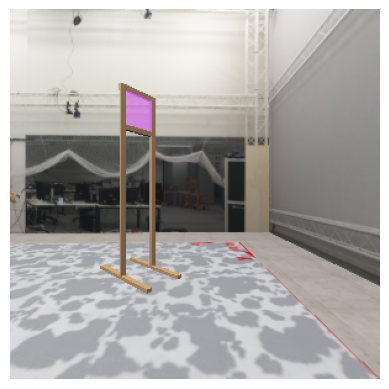

In [7]:
# Load the image
image_path = "../data/gate1.png"
image = cv2.imread(image_path)

# Display the image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [18]:
# Load the CSV file
csv_path = "../data/gate1.csv"
data = pd.read_csv(csv_path)

# Display the data
print(data)

   x_global  y_global  z_global      roll     pitch       yaw
0  0.997948  4.000196  0.990216  0.000442  0.000622 -1.593516


## Detect pink rectangle corners

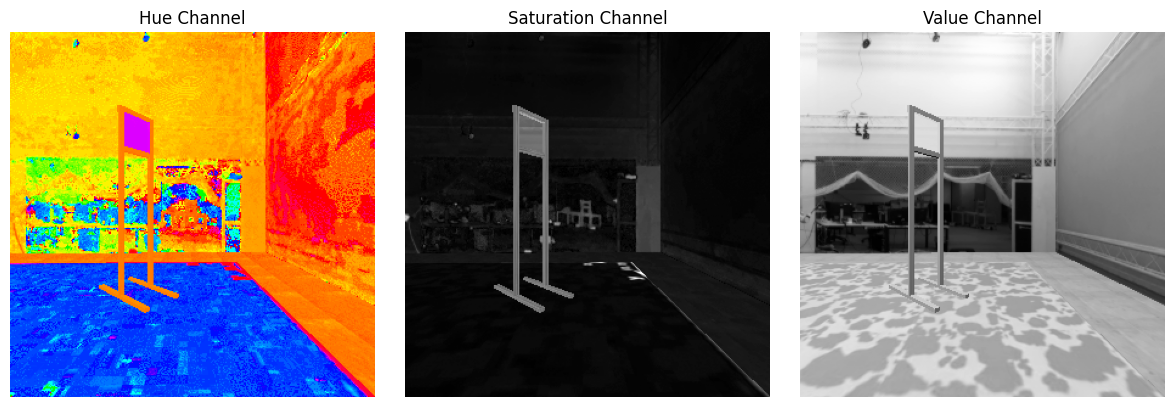

In [20]:
# Convert image to HSV color space
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Display each channel
plt.figure(figsize=(12, 4))

# Display the hue channel
plt.subplot(1, 3, 1)
plt.imshow(hsv_image[:, :, 0], cmap='hsv')
plt.title('Hue Channel')
plt.axis('off')

# Display the saturation channel
plt.subplot(1, 3, 2)
plt.imshow(hsv_image[:, :, 1], cmap='gray')
plt.title('Saturation Channel')
plt.axis('off')

# Display the value channel
plt.subplot(1, 3, 3)
plt.imshow(hsv_image[:, :, 2], cmap='gray')
plt.title('Value Channel')
plt.axis('off')

plt.tight_layout()
plt.show()


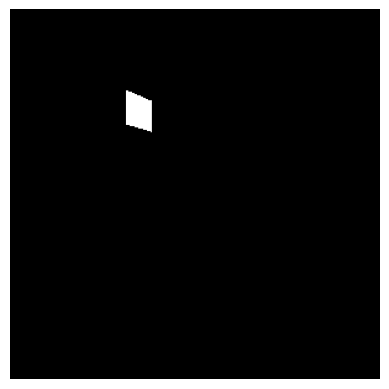

In [22]:
# Threshold the HSV image
lower_pink = np.array([140, 42, 0])
upper_pink = np.array([156, 255, 255])
mask = cv2.inRange(hsv_image, lower_pink, upper_pink)

# Display the mask
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

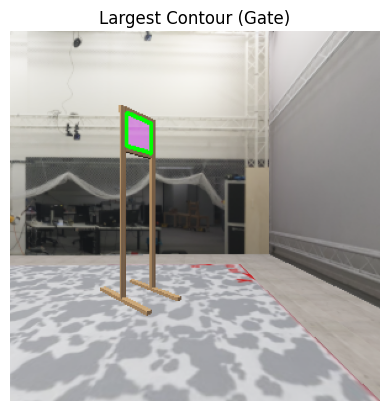

In [26]:
# Only use the largest contour
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) == 0:
    gate_contour = None
else:
    # Find the largest contour by area
    gate_contour = max(contours, key=cv2.contourArea)

# Draw the largest contour if found
output_image = image.copy()
if gate_contour is not None:
    cv2.drawContours(output_image, [gate_contour], -1, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Largest Contour (Gate)")
plt.show()


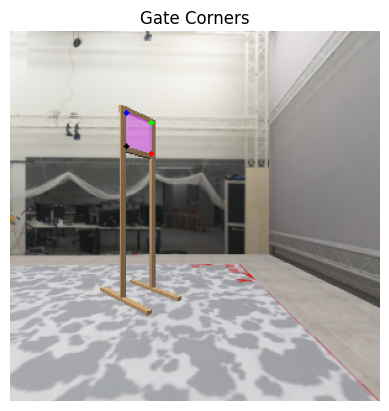

In [45]:
# Find the 4 corners of the gate contour
corners = cv2.approxPolyDP(gate_contour, 0.02 * cv2.arcLength(gate_contour, True), True)

def order_corners(pts):
    """Order points: top-left, top-right, bottom-right, bottom-left."""
    pts = pts.reshape(4, 2)
    rect = np.zeros((4, 2), dtype=int)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left has smallest x+y
    rect[2] = pts[np.argmax(s)]   # bottom-right has largest x+y
    d = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(d)]   # top-right has smallest y-x
    rect[3] = pts[np.argmax(d)]   # bottom-left has largest y-x
    return rect

corners_ordered = order_corners(corners)

# Draw the corners on the image
output_image = image.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (0, 0, 0)]  # blue, green, red, black
for i, corner in enumerate(corners_ordered):
    x, y = corner.ravel()
    cv2.circle(output_image, (int(x), int(y)), 2, colors[i], -1)  # blue circles for corners


# Display the image with corners
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Gate Corners")
plt.show()

In [46]:
print(corners_ordered)

[[ 94  66]
 [114  74]
 [114  99]
 [ 94  93]]
